增广的图片是实时生成的

In [2]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

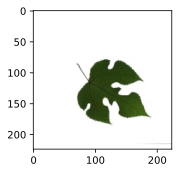

In [3]:
d2l.set_figsize()
img = d2l.Image.open(r"E:\classify-leaves\images\122.jpg")
d2l.plt.imshow(img);

大多数图像增广方法都具有一定的随机性。为了便于观察图像增广的效果，我们下面定义辅助函数apply。 此函数在输入图像img上多次运行图像增广方法aug并显示所有结果。

In [4]:
def apply(img, aug, num_rows=2, num_cols=4, scale=1.5):
    Y = [aug(img) for _ in range(num_rows * num_cols)]#aug是图像增大函数，例如可以旋转，裁剪
    d2l.show_images(Y, num_rows, num_cols, scale=scale)

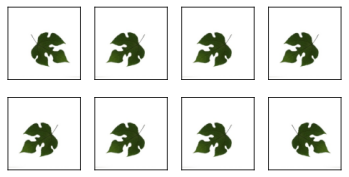

In [5]:
apply(img, torchvision.transforms.RandomHorizontalFlip())

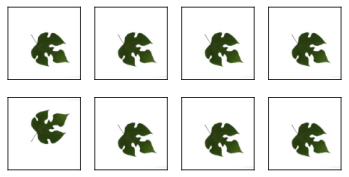

In [6]:
apply(img, torchvision.transforms.RandomVerticalFlip())

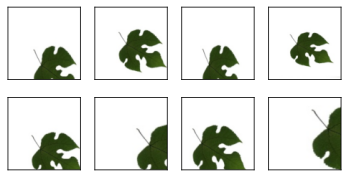

In [7]:
shape_aug=torchvision.transforms.RandomResizedCrop((200,200),scale=(0.1,1),ratio=(0.5,2))
apply(img,shape_aug)

13.1.1.2. 改变颜色

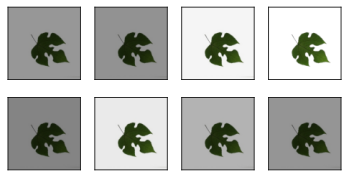

In [8]:
apply(img, torchvision.transforms.ColorJitter(
    brightness=0.5, contrast=0, saturation=0, hue=0))

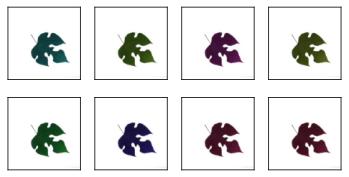

In [9]:
apply(img,torchvision.transforms.ColorJitter(brightness=0,contrast=0,saturation=0,hue=0.5))#在范围内取值

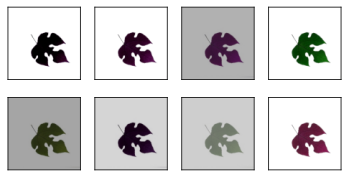

In [10]:
color_aug = torchvision.transforms.ColorJitter(
    brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5)
apply(img, color_aug)

13.1.1.3. 结合多种图像增广方法

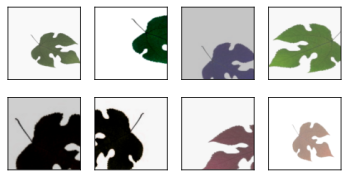

In [11]:
augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(), color_aug, shape_aug])#同时调用多种方法

apply(img, augs)

13.1.2. 使用图像增广进行训练

在datest那一步进行

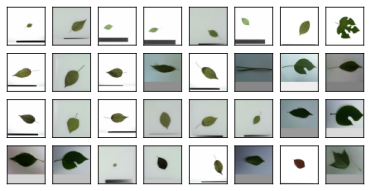

In [20]:
import os
import pandas as pd
import torch
import torchvision
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD
from sklearn.model_selection import StratifiedKFold
from PIL import Image
from d2l import torch as d2l

DATA_ROOT = 'E:\classify-leaves'
TRAIN_LABELS = 'train.csv'
# -------------------- 数据读取 --------------------
train_df = pd.read_csv(os.path.join(DATA_ROOT, TRAIN_LABELS))
all_labels = sorted(train_df['label'].unique())
label_to_idx = {label: i for i, label in enumerate(all_labels)}
idx_to_label = {i: label for label, i in label_to_idx.items()}
num_classes = len(all_labels)
train_df['label_idx'] = train_df['label'].map(label_to_idx)

class CIFAR10Dataset(Dataset):
    def __init__(self, df, transform=None, is_train=True):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def _find_image_path(self, img_id):
        return os.path.join("E:/classify-leaves", f"{img_id}")

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = str(row['image'])
        
        img_path = self._find_image_path(img_id)
        
        try:
            image = Image.open(img_path).convert('RGB')
        except FileNotFoundError:
            print(f"错误: 找不到图片文件 {img_path}")
            raise
        
        if self.transform:
          
        
        if self.is_train:
            return image, int(row['label_idx'])
        else:
            return image

train_augs = torchvision.transforms.Compose([
     torchvision.transforms.RandomHorizontalFlip(),
     torchvision.transforms.ToTensor()])

all_images=CIFAR10Dataset(train_df,train_augs,is_train=True)#就是datest上用
d2l.show_images([all_images[i][0].permute(1, 2, 0).numpy() for i in range(32)], 4, 8, scale=0.8);